In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


In [2]:
DB_PATH = Path("../olist.db")

ORDER_STATUS_FILTER = "delivered"
N_QUANTILES = 5  # standard RFM (1–5)

# From EDA: revenue is skewed, repeat customers are rare but valuable


In [3]:
with sqlite3.connect(DB_PATH) as conn:
    orders = pd.read_sql(
        """
        SELECT
            order_id,
            customer_unique_id,
            order_purchase_date,
            total_payment_value
        FROM fact_orders
        WHERE order_status = ?
        """,
        conn,
        params=(ORDER_STATUS_FILTER,),
        parse_dates=["order_purchase_date"],
    )

orders.shape


(96478, 4)

In [4]:
assert orders["order_id"].notna().all(), "order_id has nulls"
assert orders["customer_unique_id"].notna().all(), "customer_unique_id has nulls"
assert np.issubdtype(orders["order_purchase_date"].dtype, np.datetime64), "order_purchase_date not datetime"


In [5]:
invalid_monetary = orders.loc[
    (orders["total_payment_value"].isna()) | (orders["total_payment_value"] < 0),
    ["order_id", "customer_unique_id", "total_payment_value"]
]

invalid_monetary.shape


(1, 3)

In [6]:
invalid_monetary.head()


,order_id,customer_unique_id,total_payment_value
72234,bfbd0f9bdef84302105ad712db648a6c,830d5b7aaa3b6f1e9ad63703bec97d23,NaN


In [7]:
# Enforce non-negative monetary values for customer value analysis (RFM)
orders["total_payment_value"] = (
    orders["total_payment_value"]
    .fillna(0)
    .clip(lower=0)
)


In [8]:
assert orders["total_payment_value"].ge(0).all(), "Non-negative monetary invariant violated"
orders["total_payment_value"].describe()


count    96478.000000
mean       159.854700
std        218.812616
min          0.000000
25%         61.880000
50%        105.280000
75%        176.330000
max      13664.080000
Name: total_payment_value, dtype: float64

In [9]:
analysis_date = orders["order_purchase_date"].max() + pd.Timedelta(days=1)
analysis_date


Timestamp('2018-08-30 00:00:00')

In [10]:
rfm = (
    orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        recency_days=("order_purchase_date", lambda x: (analysis_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("total_payment_value", "sum"),
    )
)

rfm.head()


,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,538,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,289,1,196.89


In [11]:
rfm[["recency_days", "frequency", "monetary"]].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)


,recency_days,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,238.478877,1.033420,165.197003
std,152.595054,0.209097,226.314012
min,1.000000,1.000000,0.000000
50%,219.000000,1.000000,107.780000
75%,347.000000,1.000000,182.557500
90%,466.000000,1.000000,318.074000
95%,520.000000,1.000000,469.616500
99%,576.000000,2.000000,1097.061700
max,714.000000,15.000000,13664.080000


In [12]:
# Recency: lower is better → reverse labels
rfm["R_score"] = pd.qcut(
    rfm["recency_days"],
    q=N_QUANTILES,
    labels=list(range(N_QUANTILES, 0, -1)),
    duplicates="drop",
).astype(int)

# Frequency: many ties → rank first
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=N_QUANTILES,
    labels=list(range(1, N_QUANTILES + 1)),
    duplicates="drop",
).astype(int)

# Monetary: skewed → quantiles
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=N_QUANTILES,
    labels=list(range(1, N_QUANTILES + 1)),
    duplicates="drop",
).astype(int)

rfm[["recency_days", "frequency", "monetary", "R_score", "F_score", "M_score"]].head()


,recency_days,frequency,monetary,R_score,F_score,M_score
0,112,1,141.90,4,1,4
1,115,1,27.19,4,1,1
2,538,1,86.22,1,1,2
3,322,1,43.62,2,1,1
4,289,1,196.89,2,1,4


In [13]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm["RFM_score"].value_counts().head(10)


RFM_score
555    1009
455     962
255     892
355     883
222     854
155     848
424     843
531     840
242     838
131     824
Name: count, dtype: int64

In [14]:
conditions = [
    (rfm["R_score"] >= 4) & (rfm["F_score"] >= 4) & (rfm["M_score"] >= 4),
    (rfm["R_score"] >= 4) & (rfm["F_score"] >= 3),
    (rfm["R_score"] >= 3) & (rfm["F_score"] <= 2),
    (rfm["R_score"] <= 2) & (rfm["F_score"] >= 3),
    (rfm["R_score"] <= 2) & (rfm["F_score"] <= 2),
]

choices = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk",
    "Hibernating",
]

rfm["segment"] = np.select(conditions, choices, default="Others")

rfm["segment"].value_counts()


segment
Potential Loyalists    22421
At Risk                22154
Loyal Customers        16009
Hibernating            14922
Others                 11339
Champions               6513
Name: count, dtype: int64

In [15]:
segment_summary = (
    rfm
    .groupby("segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum"),
    )
    .sort_values("total_revenue", ascending=False)
)

segment_summary


,segment,customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue
0,At Risk,22154,395.631037,1.047892,167.027681,3700331.25
5,Potential Loyalists,22421,134.458856,1.000000,160.434449,3597100.78
2,Hibernating,14922,396.596502,1.000000,162.801958,2429330.81
1,Champions,6513,91.907262,1.180715,312.172142,2033177.16
3,Loyal Customers,16009,90.899369,1.013992,117.001107,1873070.72
4,Others,11339,221.587971,1.058030,157.813833,1789451.05


In [16]:
segment_summary["customer_share"] = segment_summary["customers"] / segment_summary["customers"].sum()
segment_summary["revenue_share"] = segment_summary["total_revenue"] / segment_summary["total_revenue"].sum()

segment_summary.sort_values("revenue_share", ascending=False)


,segment,customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue,customer_share,revenue_share
0,At Risk,22154,395.631037,1.047892,167.027681,3700331.25,0.237302,0.239931
5,Potential Loyalists,22421,134.458856,1.000000,160.434449,3597100.78,0.240162,0.233238
2,Hibernating,14922,396.596502,1.000000,162.801958,2429330.81,0.159836,0.157519
1,Champions,6513,91.907262,1.180715,312.172142,2033177.16,0.069764,0.131832
3,Loyal Customers,16009,90.899369,1.013992,117.001107,1873070.72,0.171480,0.121451
4,Others,11339,221.587971,1.058030,157.813833,1789451.05,0.121457,0.116029


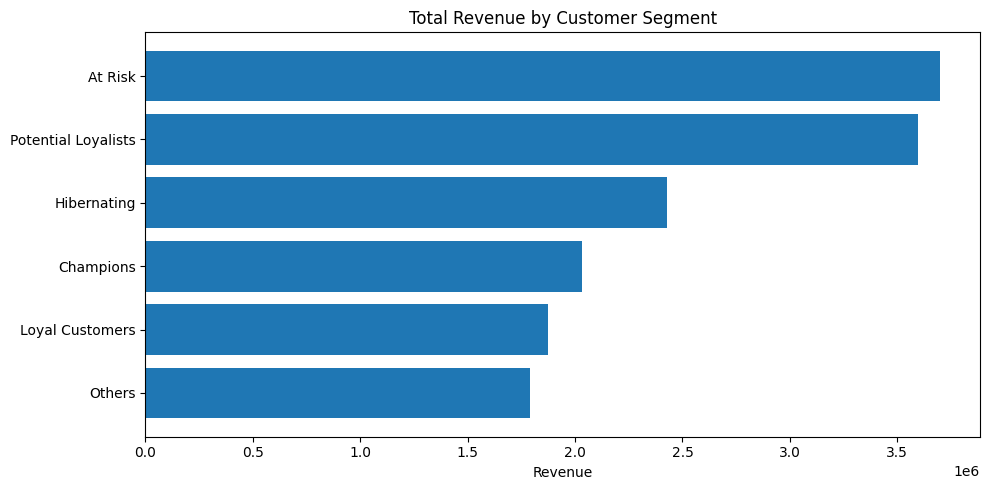

In [17]:
plot_df = segment_summary.sort_values("total_revenue")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["segment"], plot_df["total_revenue"])
plt.title("Total Revenue by Customer Segment")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()


In [18]:
Path("../data/processed").mkdir(exist_ok=True)

rfm.to_csv("../data/processed/rfm_segments.csv", index=False)
segment_summary.to_csv("../data/processed/rfm_segment_summary.csv", index=False)

print("Saved:")
print("- ../data/processed/rfm_segments.csv")
print("- ../data/processed/rfm_segment_summary.csv")


Saved:
- ../data/processed/rfm_segments.csv
- ../data/processed/rfm_segment_summary.csv
